# Attack result plots

Exploratory views of stored attack results. Nothing here trains a model or writes
a file — it reads `results/` and draws on screen.

For the fixed figures that go in the paper, use the generator instead:

```bash
python experiments/figures/attack_figures.py --attribute all
```


In [6]:
%matplotlib inline
from experiments.figures import explore

## What is available

Read live from `results/`, so it cannot go stale as experiments are added or
re-run. Call with no arguments for everything, or narrow to one dataset.

In [7]:
explore.options("ml-100k")

# explore.options()                 # every dataset
# explore.options("ml-1m", "age")   # one dataset, one attribute

ml-100k  (ML100K)
  attributes: gender, age
  gender:
    attacks (9): bandwagon, cfair_favorite_push_least_favorite, cfair_favorite_push_random, cfair_influencer_nuke_favorite, cfair_influencer_push_least_favorite, cfair_influencer_push_random, cfair_reverse_favorite_nuke_favorite, power_user, reverse_bandwagon
    models  (13): bnslim-u-gender, ease-i, ease-u, mf, mf-absolute-gender, mf-over-gender, mf-under-gender, mf-value-gender, neumf, nmf, slim-i, slim-u, svd
    budgets: [0.0, 0.1, 0.25]
  age:
    attacks (6): cfair_favorite_push_least_favorite, cfair_favorite_push_random, cfair_influencer_nuke_favorite, cfair_influencer_push_least_favorite, cfair_influencer_push_random, cfair_reverse_favorite_nuke_favorite
    models  (13): bnslim-u-age, ease-i, ease-u, mf, mf-absolute-age, mf-over-age, mf-under-age, mf-value-age, neumf, nmf, slim-i, slim-u, svd
    budgets: [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
  metrics: ndcg, precision, recall



## Plot

Only `dataset` is required; everything else defaults to what the results contain.
Four panels against attack budget: the benefit ratio $\gamma$, the absolute
benefit gap $\Delta m$, and each group's score. The dashed line marks the
four-fifths threshold.

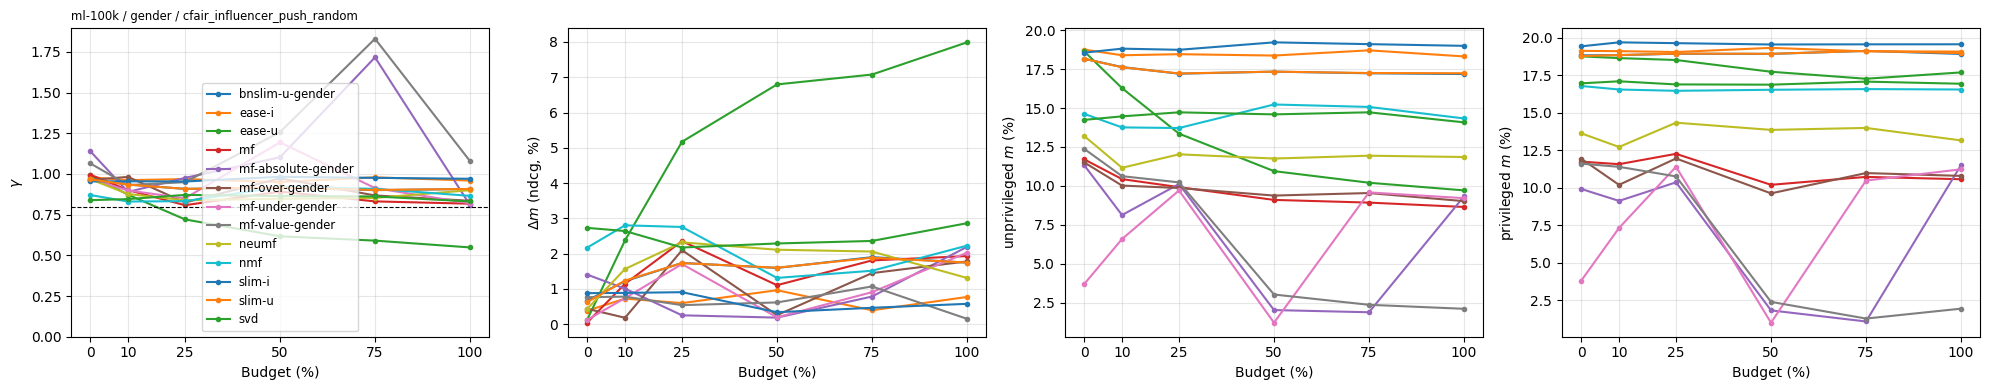

In [8]:
explore.plot_attack("ml-100k", attack_id="cfair_influencer_push_random");

Narrow it down when you want to — a subset of models, a different metric,
specific budgets, or the age attribute where it was run.

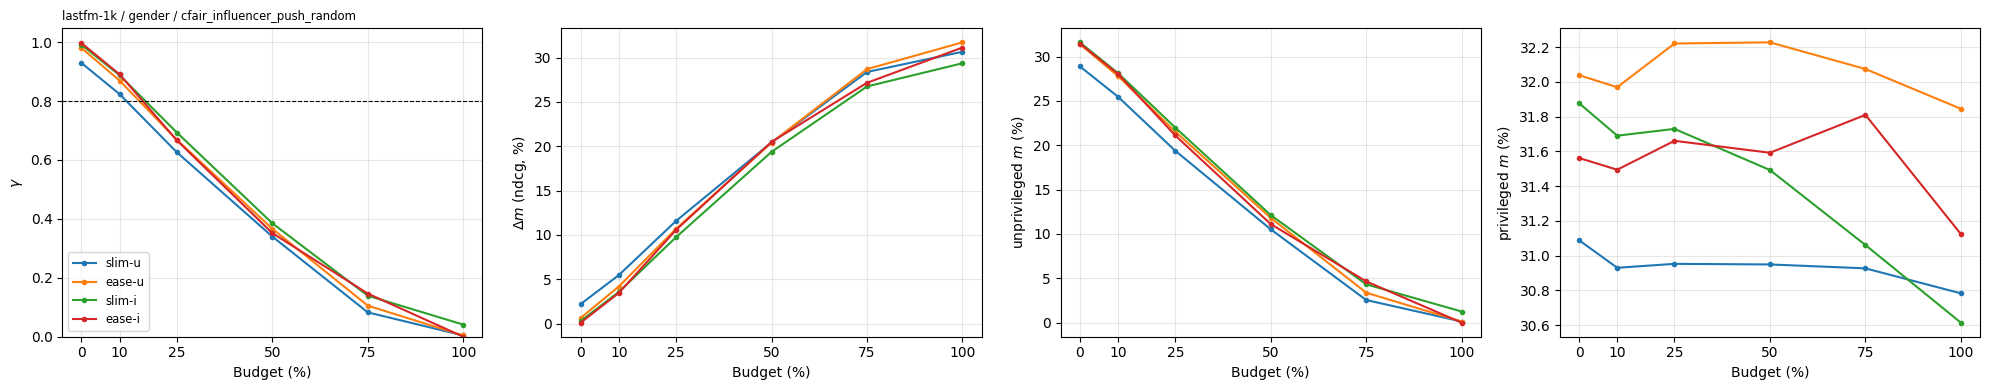

In [9]:
explore.plot_attack(
    "lastfm-1k",
    attribute="gender",
    attack_id="cfair_influencer_push_random",
    models_to_plot=["slim-u", "ease-u", "slim-i", "ease-i"],
    metric="ndcg",
);

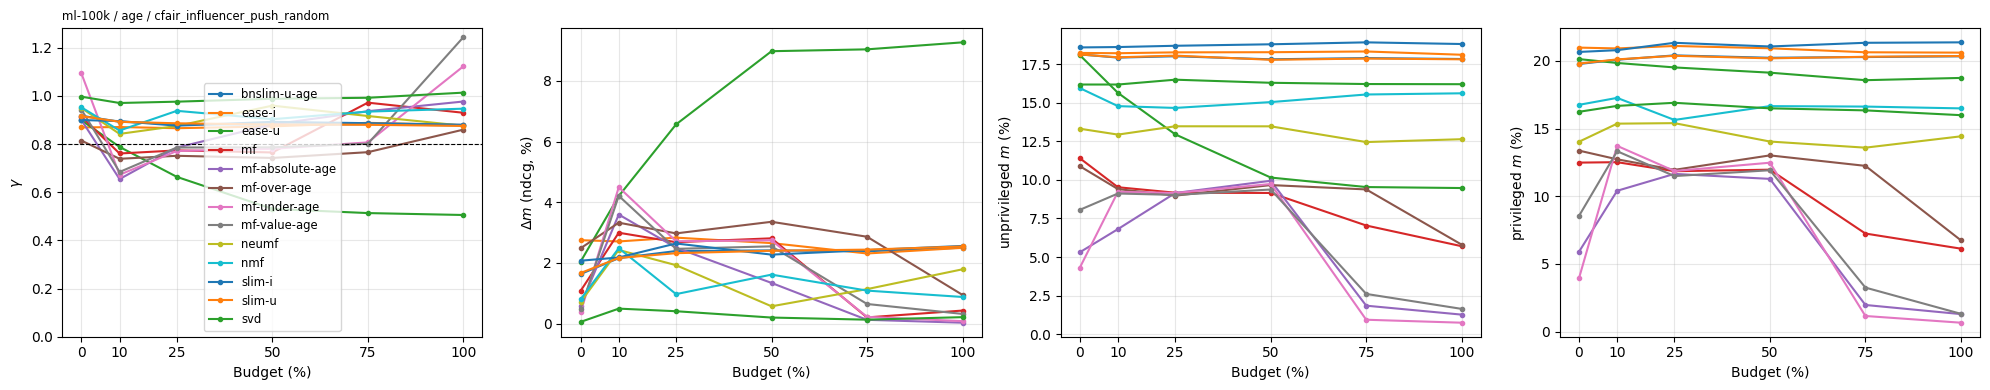

In [10]:
# Age was only run for the C-fair attacks, on ML100K, ML1M and LFM1K.
explore.plot_attack("ml-100k", attribute="age",
                    attack_id="cfair_influencer_push_random");